In [ ]:
import sys
from pathlib import Path
# Make the repo root importable regardless of CWD or machine: walk up from the
# working dir until we hit a repo marker, then put that dir on sys.path.
_start = Path.cwd()
_root = next((p for p in (_start, *_start.parents)
              if (p / ".git").exists() or (p / "setup.py").exists()), _start)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

In [1]:
from metab_processing.metab_travlr_config import PROJECT_DATA_DIR, DATA_DIR as METAB_DATA_DIR

XENIUM_DATA_DIR = PROJECT_DATA_DIR
DATASET_NAME = 'Human_Lung'
DATA_DIR = f'{XENIUM_DATA_DIR}/{DATASET_NAME}'
EASY_DOWNLOAD_PATH = f'{DATA_DIR}/easy_download'


In [2]:
import harreman
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
import warnings
import json
import os
warnings.filterwarnings("ignore")

In [3]:
adata = sc.read_h5ad(f'{XENIUM_DATA_DIR}/{DATASET_NAME}/adata.h5ad')
adata.layers['counts'] = adata.X
adata

AnnData object with n_obs × n_vars = 278328 × 5001
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', '_scvi_batch', '_scvi_labels', 'leiden_scVI_res_0.5', 'leiden_scVI_res_0.75', 'leiden_scVI_res_0.65', 'leiden_scVI_res_0.375', 'leiden_scVI_res_0.25', 'leiden_scVI_res_1.5', 'leiden_scVI_res_0.1', 'leiden_scVI_res_0.05', 'leiden_scVI_res_2.5', 'leiden_scVI_res_2', 'leiden_scVI_res_1'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scVI_res_0.05', 'leiden_scVI_res_0.05_colors', 'leiden_scVI_res_0.1', 'leiden_scVI_res_0.1_colors', 'leiden_scVI_res_0.25', 'leiden_scVI_res_0.25_colors', 'leiden_scVI_res_0.375', 'leiden_scVI_res_0.375_colors', 'leiden_scVI_res_0.5', 'leiden_scVI_res_0.5_colors', 'leiden_scVI_res_0.

In [4]:
def save_harreman_network(adata, save_dir):
    """Run this before doing anything else to get a baseline of the availible pathways.
    You will need to redo compute gene pairs if you filter after."""
    # Start fresh with transporter database only
    harreman.pp.extract_interaction_db(
        adata,
        species='human',
        database='transporter',   # metabolic transporters only, not LR pairs
        extracellular_only=True,
    )

    # Recompute KNN graph (in case it needs refreshing)
    harreman.tl.compute_knn_graph(
        adata,
        compute_neighbors_on_key='spatial',
        n_neighbors=5,
        weighted_graph=False,
        # sample_key='sample',
    )

    harreman.tl.compute_gene_pairs(adata, ct_specific=False, verbose=False)
    
    db_key = adata.uns['database_varm_key']
    db = pd.DataFrame(adata.varm[db_key], index=adata.var_names)
    transporter_genes = db.index[db.any(axis=1)].tolist()
    num_transporter_genes = len(transporter_genes)
    gp_per_metabolite = adata.uns['gene_pairs_per_metabolite']
    gp = adata.uns['gene_pairs']
    num_metab = len(gp_per_metabolite)
    num_gp = len(gp)
    metabolite_pair_counts = {metabolite: len(info['gene_pair']) for metabolite, info in gp_per_metabolite.items()}
    to_save = {
        'num_transporter_genes': num_transporter_genes,
        'num_metab': num_metab,
        'num_gp': num_gp,
        'metabolite_pair_counts': metabolite_pair_counts,
        'transporter_gense': transporter_genes,
        'gp': gp,
        'gp_per_metabolite': gp_per_metabolite,
    }
    save_path = f'{save_dir}/harreman_network.json'
    os.makedirs(save_dir, exist_ok=True)
    with open(save_path, "w") as file:
        json.dump(to_save, file)

In [5]:
save_harreman_network(adata, EASY_DOWNLOAD_PATH)

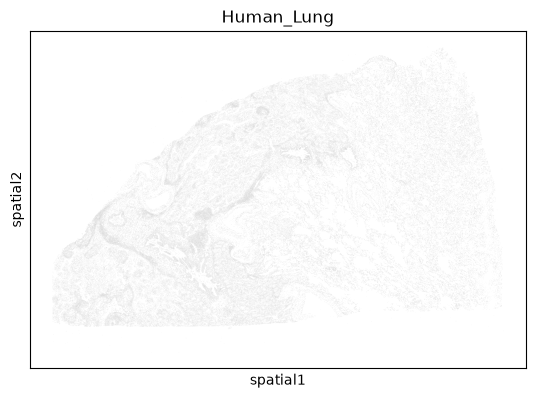

In [6]:
sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME);

In [4]:
# Make sure raw counts are stored
adata.layers['counts'] = adata.X.copy()

# Normalize and log-transform, store as a layer
adata.X = adata.layers['counts'].copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers['log_norm'] = adata.X.copy()

# Restore raw counts as X
adata.X = adata.layers['counts'].copy()

In [6]:
# sample_col = 'sample'
n_genes_expr = 50
# genes_to_keep = np.zeros(adata.shape[1], dtype=bool)

# for sample in adata.obs[sample_col].unique():
#     adata_sample = adata[adata.obs[sample_col] == sample]
#     expressed = np.array((adata_sample.X > 0).sum(axis=0)).flatten()
#     genes_to_keep |= expressed >= n_genes_expr
adata = adata[:, np.array((adata.X > 0).sum(axis=0)).flatten() >= n_genes_expr].copy()

In [5]:
adata

AnnData object with n_obs × n_vars = 278328 × 5001
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', '_scvi_batch', '_scvi_labels', 'leiden_scVI_res_0.5', 'leiden_scVI_res_0.75', 'leiden_scVI_res_0.65', 'leiden_scVI_res_0.375', 'leiden_scVI_res_0.25', 'leiden_scVI_res_1.5', 'leiden_scVI_res_0.1', 'leiden_scVI_res_0.05', 'leiden_scVI_res_2.5', 'leiden_scVI_res_2', 'leiden_scVI_res_1'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scVI_res_0.05', 'leiden_scVI_res_0.05_colors', 'leiden_scVI_res_0.1', 'leiden_scVI_res_0.1_colors', 'leiden_scVI_res_0.25', 'leiden_scVI_res_0.25_colors', 'leiden_scVI_res_0.375', 'leiden_scVI_res_0.375_colors', 'leiden_scVI_res_0.5', 'leiden_scVI_res_0.5_colors', 'leiden_scVI_res_0.

In [6]:
t_cell_markers = ['CD3D', 'CD3E', 'CD3G', 'CD8A', 'CD8B', 'CD4', 'FOXP3']
sc.tl.score_genes(adata, gene_list=t_cell_markers, score_name='t_cell_score')

In [24]:
# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)
# sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
# adata = adata[:, adata.var.highly_variable]

In [7]:
adata

AnnData object with n_obs × n_vars = 278328 × 5001
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', '_scvi_batch', '_scvi_labels', 'leiden_scVI_res_0.5', 'leiden_scVI_res_0.75', 'leiden_scVI_res_0.65', 'leiden_scVI_res_0.375', 'leiden_scVI_res_0.25', 'leiden_scVI_res_1.5', 'leiden_scVI_res_0.1', 'leiden_scVI_res_0.05', 'leiden_scVI_res_2.5', 'leiden_scVI_res_2', 'leiden_scVI_res_1', 't_cell_score'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scVI_res_0.05', 'leiden_scVI_res_0.05_colors', 'leiden_scVI_res_0.1', 'leiden_scVI_res_0.1_colors', 'leiden_scVI_res_0.25', 'leiden_scVI_res_0.25_colors', 'leiden_scVI_res_0.375', 'leiden_scVI_res_0.375_colors', 'leiden_scVI_res_0.5', 'leiden_scVI_res_0.5_colors', 'le

In [26]:
# sc.tl.pca(adata, svd_solver='arpack')
# sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

In [ ]:
# sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30)

In [ ]:
# # Step 1: Calculate UMAP for each sample
# sub_adatas = [adata[adata.obs['sample'] == s].copy() for s in adata.obs['sample'].unique()]
# for sub in sub_adatas:
#     sc.pp.neighbors(sub, n_pcs=30)
#     sc.tl.umap(sub)

In [ ]:
# # Step 2: Plot t_cell_score for each sample
# for sub in sub_adatas:
#     sc.pl.umap(sub, color='t_cell_score', cmap='Reds', vmin=0, title=sub.obs['sample'].iloc[0])

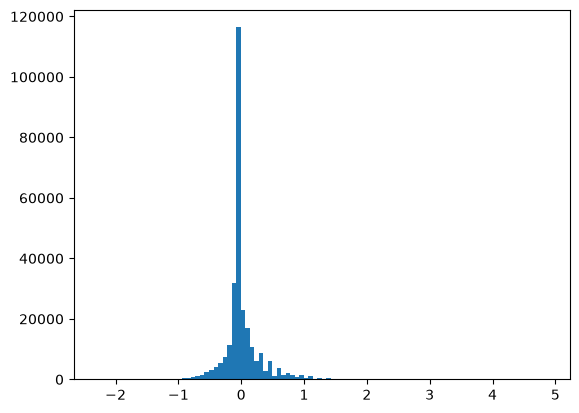

In [8]:
plt.hist(adata.obs['t_cell_score'], bins=100);

In [9]:
adata.obs['cell_type'] = 'other'  # this creates the column

# Add 'T cell' as a category before assigning
adata.obs['cell_type'] = adata.obs['cell_type'].astype(str)  # convert out of categorical
adata.obs.loc[adata.obs['t_cell_score'] > 0.1, 'cell_type'] = 'T cell'
adata.obs['cell_type'] = adata.obs['cell_type'].astype('category')  # back to categorical

print(adata.obs['cell_type'].value_counts())

cell_type
other     216275
T cell     62053
Name: count, dtype: int64


In [10]:
# Start fresh with transporter database only
harreman.pp.extract_interaction_db(
    adata,
    species='human',
    database='transporter',   # metabolic transporters only, not LR pairs
    extracellular_only=True,
    verbose=True
)

# Check how many genes are in the database
print("Genes in transporter database:")
db_key = adata.uns['database_varm_key']
print(adata.varm[db_key].shape)

# Rerun gene filtering
harreman.tl.apply_gene_filtering(
    adata,
    layer_key='counts',
    model='bernoulli',
    autocorrelation_filt=False,
    verbose=True
)

# Check what's actually stored
print(type(adata.uns['expression_filt']))
print(adata.uns['expression_filt'])
print(adata.uns['de_filt'])

# Check the database key and what genes are in it
db_key = adata.uns['database_varm_key']
print(f"\nDatabase key: {db_key}")
print(f"Database shape: {adata.varm[db_key].shape}")

# Get the transporter genes that are in your adata
import pandas as pd
db = pd.DataFrame(adata.varm[db_key], index=adata.var_names)
transporter_genes = db.index[db.any(axis=1)].tolist()
print(f"\nTransporter genes in your dataset: {len(transporter_genes)}")
print(transporter_genes[:30])

# Check their expression
import numpy as np
if len(transporter_genes) > 0:
    expr = np.array(adata[:, transporter_genes].layers['counts'].sum(axis=0)).flatten()
    n_spots_expressed = (np.array(adata[:, transporter_genes].layers['counts'].toarray()) > 0).sum(axis=0)
    gene_stats = pd.DataFrame({
        'gene': transporter_genes,
        'total_counts': expr,
        'n_spots': n_spots_expressed
    }).sort_values('total_counts', ascending=False)
    print("\nTop 20 transporter genes by expression:")
    print(gene_stats.head(20))
    print(f"\nGenes expressed in >100 spots: {(gene_stats['n_spots'] > 100).sum()}")
    print(f"Genes expressed in >50 spots: {(gene_stats['n_spots'] > 50).sum()}")
    print(f"Genes expressed in >10 spots: {(gene_stats['n_spots'] > 10).sum()}")

Extracting interaction database...
Finished extracting interaction database in 0.498 seconds
Genes in transporter database:
(5001, 160)
Applying gene filtering...
Finished applying gene filtering in 0.000 seconds
<class 'bool'>
False
False

Database key: database
Database shape: (5001, 160)

Transporter genes in your dataset: 100
['ABCA1', 'ABCB1', 'ABCC1', 'ABCC2', 'ABCC3', 'ABCC4', 'ABCC8', 'ABCG2', 'AQP4', 'AQP5', 'AQP7', 'AQP8', 'AQP9', 'ATP7A', 'ATP7B', 'CD36', 'CD38', 'CHRNA5', 'CLCN3', 'CLCN4', 'CLCN5', 'CPT1A', 'CUBN', 'FOLR1', 'FOLR2', 'LRP1', 'LRP2', 'MSR1', 'NPC1L1', 'ORAI2']

Top 20 transporter genes by expression:
       gene  total_counts  n_spots
73  SLC40A1      359550.0    98341
98     TAP1      143024.0    68386
23    FOLR1      135074.0    46006
65   SLC2A3      100965.0    55293
33   SCNN1A       99079.0    41543
37  SLC11A2       76674.0    47521
38  SLC12A2       70143.0    35050
97  SLCO2B1       66509.0    30925
27     MSR1       66295.0    22005
4     ABCC3    

In [11]:
# Recompute KNN graph (in case it needs refreshing)
harreman.tl.compute_knn_graph(
    adata,
    compute_neighbors_on_key='spatial',
    n_neighbors=5,
    weighted_graph=False,
    # sample_key='sample',
    verbose=True
)

# Compute gene pairs with transporter database only
harreman.tl.compute_gene_pairs(adata, ct_specific=False, verbose=True)
print(f"Gene pairs to test: {len(adata.uns.get('gene_pairs', []))}")

# Run communication
harreman.tl.compute_cell_communication(
    adata,
    model='bernoulli',
    M=50,
    test='both',
    layer_key_p_test='counts',
    layer_key_np_test='log_norm',
    verbose=True
)

# Check results before filtering
df = adata.uns['ccc_results']['cell_com_df_gp'].copy()
print(f"\nTotal pairs tested: {len(df)}")
print(f"Non-zero C scores: {(df['C_np'] != 0).sum()}")
print(f"\nTop 10 by C score:")
print(df.sort_values('C_np', ascending=False).head(10)[['Gene 1', 'Gene 2', 'C_np', 'FDR_np']])

Computing the neighborhood graph...
Computing the weights...
Finished computing the KNN graph in 2.577 seconds
Computing gene pairs...
Finished computing gene pairs in 0.100 seconds
Gene pairs to test: 416
Starting cell-cell communication analysis...
Running the parametric test...
Parametric test finished.
Running the non-parametric test...


Permutation test: 100%|██████████| 50/50 [06:01<00:00,  7.24s/it]


Non-parametric test finished.
Obtaining communication results...
Finished computing cell-cell communication analysis in 380.869 seconds

Total pairs tested: 416
Non-zero C scores: 404

Top 10 by C score:
      Gene 1   Gene 2          C_np    FDR_np
76   SLC40A1  SLC40A1  3.665328e+06  0.042264
78   SLC11A2  SLC40A1  2.619458e+06  0.042264
80    SLC3A2  SLC40A1  1.489403e+06  0.042264
338     TAP1     TAP1  1.375281e+06  0.042264
220    ABCC3    FOLR1  1.223913e+06  0.042264
236    FOLR1    FOLR1  1.105325e+06  0.042264
11    SLC2A3   SLC2A3  1.039080e+06  0.042264
170  SLC12A2  SLC29A1  7.692184e+05  0.042264
409   SCNN1A   SCNN1A  7.580495e+05  0.042264
148  SLC12A2   SLC1A5  7.112995e+05  0.042264


In [16]:
# Check what the gene_pairs actually contain
gp = adata.uns['gene_pairs']
gp_per_metabolite = adata.uns['gene_pairs_per_metabolite']

In [13]:
gp_per_metabolite

{'D-Glucose': {'gene_pair': [('SLC2A9', 'SLC2A9'),
   ('SLC2A4', 'SLC2A9'),
   ('SLC2A3', 'SLC2A4'),
   ('SLC2A1', 'SLC2A4'),
   ('SLC2A1', 'SLC2A1'),
   ('SLC2A3', 'SLC2A9'),
   ('SLC2A1', 'SLC2A9'),
   ('SLC2A2', 'SLC2A9'),
   ('SLC2A2', 'SLC2A4'),
   ('SLC2A1', 'SLC2A2'),
   ('SLC2A2', 'SLC2A2'),
   ('SLC2A3', 'SLC2A3'),
   ('SLC2A1', 'SLC2A3'),
   ('SLC2A4', 'SLC2A4'),
   ('SLC2A2', 'SLC2A3')],
  'gene_type': [('IMP-EXP', 'IMP-EXP'),
   ('IMP-EXP', 'IMP-EXP'),
   ('IMP-EXP', 'IMP-EXP'),
   ('IMP-EXP', 'IMP-EXP'),
   ('IMP-EXP', 'IMP-EXP'),
   ('IMP-EXP', 'IMP-EXP'),
   ('IMP-EXP', 'IMP-EXP'),
   ('IMP-EXP', 'IMP-EXP'),
   ('IMP-EXP', 'IMP-EXP'),
   ('IMP-EXP', 'IMP-EXP'),
   ('IMP-EXP', 'IMP-EXP'),
   ('IMP-EXP', 'IMP-EXP'),
   ('IMP-EXP', 'IMP-EXP'),
   ('IMP-EXP', 'IMP-EXP'),
   ('IMP-EXP', 'IMP-EXP')]},
 'D-Galactose': {'gene_pair': [('SLC2A1', 'SLC2A1'),
   ('SLC2A1', 'SLC2A2'),
   ('SLC2A2', 'SLC2A2'),
   ('SLC2A3', 'SLC2A3'),
   ('SLC2A1', 'SLC2A3'),
   ('SLC2A2', 'SLC2A3')],

In [32]:
# Check what the gene_pairs actually contain
gp = adata.uns['gene_pairs']
gp_per_metabolite = adata.uns['gene_pairs_per_metabolite']

print(f"Total gene pairs: {len(gp)}")
print(f"Total metabolites with pairs: {len(gp_per_metabolite)}")
print(f"\nMetabolites covered:")
for met in list(gp_per_metabolite.keys())[:20]:
    print(f"  {met}")

# Check importer/exporter info stored by harreman
print("\nKeys related to import/export:")
print(adata.uns.get('importer', 'not found'))
print(adata.uns.get('exporter', 'not found'))
print(adata.uns.get('import_export', 'not found'))

# Look at actual pair structure
print("\nFirst 10 gene pairs and their structure:")
for i, pair in enumerate(gp[:10]):
    print(f"  {pair}")

Total gene pairs: 416
Total metabolites with pairs: 160

Metabolites covered:
  D-Glucose
  D-Galactose
  D-Mannose
  Glucosamine
  Docosahexaenoic acid
  D-Xylose
  L-Glutamine
  L-Alanine
  L-Asparagine
  L-Cysteine
  L-Histidine
  L-Serine
  L-Methionine
  L-Threonine
  L-Lactate
  Pyruvate
  Ketone bodies
  Nicotinate
  Butyrate
  L-Glutamate

Keys related to import/export:
Empty DataFrame
Columns: [IMPORT0, IMPORT1, IMPORT2, IMPORT3, IMPORT4, IMPORT5, IMPORT6, IMPORT7, IMPORT8, IMPORT9, IMPORT10, IMPORT11, IMPORT12, IMPORT13, IMPORT14, IMPORT15, IMPORT16, IMPORT17, IMPORT18, IMPORT19, IMPORT20, IMPORT21, IMPORT22, IMPORT23, IMPORT24, IMPORT25, IMPORT26, IMPORT27, IMPORT28, IMPORT29, IMPORT30, IMPORT31, IMPORT32, IMPORT33, IMPORT34, IMPORT35, IMPORT36, IMPORT37, IMPORT38, IMPORT39, IMPORT40, IMPORT41, IMPORT42, IMPORT43, IMPORT44, IMPORT45, IMPORT46, IMPORT47, IMPORT48, IMPORT49, IMPORT50, IMPORT51, IMPORT52, IMPORT53, IMPORT54, IMPORT55, IMPORT56, IMPORT57, IMPORT58, IMPORT59, IMP

In [ ]:
print(gp_per_metabolite)

{'D-Glucose': {'gene_pair': [('SLC2A1', 'SLC2A1'), ('SLC2A1', 'SLC2A9'), ('SLC2A3', 'SLC2A4'), ('SLC2A2', 'SLC2A3'), ('SLC2A1', 'SLC2A3'), ('SLC2A2', 'SLC2A2'), ('SLC2A3', 'SLC2A9'), ('SLC2A2', 'SLC2A4'), ('SLC2A4', 'SLC2A4'), ('SLC2A9', 'SLC2A9'), ('SLC2A1', 'SLC2A2'), ('SLC2A4', 'SLC2A9'), ('SLC2A1', 'SLC2A4'), ('SLC2A3', 'SLC2A3'), ('SLC2A2', 'SLC2A9')], 'gene_type': [('IMP-EXP', 'IMP-EXP'), ('IMP-EXP', 'IMP-EXP'), ('IMP-EXP', 'IMP-EXP'), ('IMP-EXP', 'IMP-EXP'), ('IMP-EXP', 'IMP-EXP'), ('IMP-EXP', 'IMP-EXP'), ('IMP-EXP', 'IMP-EXP'), ('IMP-EXP', 'IMP-EXP'), ('IMP-EXP', 'IMP-EXP'), ('IMP-EXP', 'IMP-EXP'), ('IMP-EXP', 'IMP-EXP'), ('IMP-EXP', 'IMP-EXP'), ('IMP-EXP', 'IMP-EXP'), ('IMP-EXP', 'IMP-EXP'), ('IMP-EXP', 'IMP-EXP')]}, 'D-Galactose': {'gene_pair': [('SLC2A1', 'SLC2A1'), ('SLC2A2', 'SLC2A3'), ('SLC2A1', 'SLC2A3'), ('SLC2A2', 'SLC2A2'), ('SLC2A1', 'SLC2A2'), ('SLC2A3', 'SLC2A3')], 'gene_type': [('IMP-EXP', 'IMP-EXP'), ('IMP-EXP', 'IMP-EXP'), ('IMP-EXP', 'IMP-EXP'), ('IMP-EXP', 'IM

In [38]:
metabolite_pair_counts = {metabolite: len(info['gene_pair']) for metabolite, info in gp_per_metabolite.items()}
print(metabolite_pair_counts)

{'D-Glucose': 15, 'D-Galactose': 6, 'D-Mannose': 6, 'Glucosamine': 6, 'Docosahexaenoic acid': 6, 'D-Xylose': 1, 'L-Glutamine': 15, 'L-Alanine': 1, 'L-Asparagine': 1, 'L-Cysteine': 6, 'L-Histidine': 1, 'L-Serine': 3, 'L-Methionine': 3, 'L-Threonine': 1, 'L-Lactate': 3, 'Pyruvate': 1, 'Ketone bodies': 1, 'Nicotinate': 6, 'Butyrate': 1, 'L-Glutamate': 28, 'L-Aspartate': 3, 'D-Aspartate': 3, 'L-Cystine': 6, 'Zinc': 3, 'Iron': 15, 'Cadmium': 1, 'Manganese': 3, 'Acetyl-L-Carnitine': 3, 'L-Carnitine': 15, 'Sodium': 78, 'Prostaglandins': 6, 'Acetate': 6, 'L-Leucine': 10, 'L-Arginine': 3, 'Fatty acid': 6, 'Creatine': 1, 'GABA': 3, 'Choline': 10, 'Thyroxine': 3, 'L-Phenylalanine': 3, 'L-Tyrosine': 1, '25-Hydroxycholesterol': 1, 'Cholesterol': 6, 'Dopamine': 10, 'D-Lactate': 1, 'Phosphate': 6, 'Serotonin': 6, 'Thiamine': 1, 'Ethanol': 3, 'Folic acid': 21, 'Heme': 3, 'Spermine': 3, 'Putrescine': 1, 'Citric acid': 1, 'Malic acid': 1, 'L-Valine': 1, 'L-Isoleucine': 1, 'Adenine': 1, 'L-Lysine': 1, 'L

In [39]:
harreman.tl.select_significant_interactions(adata, test='non-parametric', threshold=0.05)

In [40]:
adata.uns['ccc_results']['cell_com_df_gp_sig']

,Gene 1,Gene 2,C_p,Z,Z_pval,Z_FDR,C_norm_p,C_np,pval_np,FDR_np,C_norm_np,selected
0,SLC2A1,SLC2A1,60965.398794,38.382147,0.000000e+00,0.000000e+00,0.069410,55562.661912,0.004975,0.011435,0.110846,True
1,SLC2A1,SLC2A9,5549.091303,2.746920,3.007892e-03,6.951572e-03,0.006318,15292.741451,0.004975,0.011435,0.030509,True
6,SLC2A3,SLC2A9,13866.224959,6.048272,7.320391e-10,2.114780e-09,0.013566,77441.587411,0.004975,0.011435,0.019363,True
8,SLC2A4,SLC2A4,20101.427460,12.655309,5.228176e-37,2.037577e-36,0.014693,676.882521,0.004975,0.011435,0.017195,True
9,SLC2A9,SLC2A9,13870.543969,8.732515,1.245355e-18,4.177966e-18,0.016230,3868.615234,0.004975,0.011435,0.024275,True
...,...,...,...,...,...,...,...,...,...,...,...,...
408,ORAI3,ORAI3,29619.653866,18.647724,6.588441e-78,3.011859e-77,0.033841,56088.073320,0.004975,0.011435,0.079780,True
409,SCNN1A,SCNN1G,78626.414823,33.488044,3.598011e-246,2.672808e-245,0.105276,126757.858001,0.004975,0.011435,0.065398,True
410,SCNN1A,SCNN1A,194892.160418,122.698773,0.000000e+00,0.000000e+00,0.260949,758049.533069,0.004975,0.011435,0.391098,True
411,SCNN1G,SCNN1G,127637.957149,80.357366,0.000000e+00,0.000000e+00,0.139796,36824.170089,0.004975,0.011435,0.152860,True


In [ ]:
# counts_per_sample = adata.obs.groupby(['sample', 'cell_type']).size().unstack(fill_value=0)
# good_samples = counts_per_sample[counts_per_sample['T cell'] >= 20].index.tolist()
# print("Samples kept:", good_samples)

# adata_sub = adata[adata.obs['sample'].isin(good_samples)].copy()

Samples kept: ['s1', 's2', 's3', 's4', 's7', 's8', 's9', 's10']


In [15]:
# Get the significant gene pairs from step 5 to focus on
cell_communication_df = adata.uns['ccc_results']['cell_com_df_gp_sig'].copy()
gene_pairs_filt = list(zip(cell_communication_df['Gene 1'], cell_communication_df['Gene 2']))

KeyError: 'cell_com_df_gp_sig'

In [ ]:
cell_communication_df

In [44]:
# Get the significant gene pairs from step 5 to focus on
cell_communication_df = adata.uns['ccc_results']['cell_com_df_gp_sig'].copy()
gene_pairs_filt = list(zip(cell_communication_df['Gene 1'], cell_communication_df['Gene 2']))

# Compute cell-type-specific gene pairs
harreman.tl.compute_gene_pairs(adata, cell_type_key='cell_type', verbose=True)

# Run Test 8 — cell-type-specific metabolite crosstalk
harreman.tl.compute_ct_cell_communication(
    adata,
    model='bernoulli',
    cell_type_key='cell_type',
    M=1000,
    test='both',
    layer_key_p_test='counts',
    layer_key_np_test='log_norm',
    subset_gene_pairs=gene_pairs_filt,
    fix_gp=False,           # False = Test 8 (metabolite level)
    verbose=True
)

harreman.tl.select_significant_interactions(
    adata,
    test='non-parametric',
    ct_aware=True,
    threshold=0.05
)

Computing gene pairs...
Finished computing gene pairs in 0.300 seconds
Starting cell type-aware cell-cell communication analysis...
Running the parametric test...
Running the non-parametric test...


Permutation test: 100%|██████████| 1000/1000 [01:48<00:00,  9.18it/s]


Non-parametric test finished.
Obtaining cell type-aware communication results...
Finished computing cell type-aware cell-cell communication analysis in 111.127 seconds


In [45]:
# Get the metabolite-level results
results = adata.uns['ct_ccc_results']['cell_com_df_m'].copy()

# Filter to interactions involving T cells
t_cell_results = results[
    (results['Cell Type 1'] == 'T cell') | (results['Cell Type 2'] == 'T cell')
]

# Show significant ones
sig_t_cell = t_cell_results[t_cell_results['selected'] == True]
print(sig_t_cell[['Cell Type 1', 'Cell Type 2', 'metabolite']].sort_values('metabolite'))

    Cell Type 1 Cell Type 2                                         metabolite
0        T cell      T cell  (3a,5b,7a)-23-Carboxy-7-hydroxy-24-norcholan-3...
154      T cell       other  (3a,5b,7a)-23-Carboxy-7-hydroxy-24-norcholan-3...
2        T cell      T cell             1b,3a,12a-Trihydroxy-5b-cholanoic acid
156      T cell       other             1b,3a,12a-Trihydroxy-5b-cholanoic acid
4        T cell      T cell                              25-Hydroxycholesterol
..          ...         ...                                                ...
151      T cell      T cell                                               Zinc
305      T cell       other                                               Zinc
306      T cell       other                          alpha-Ketoisovaleric acid
153      T cell      T cell                                   alpha-Tocopherol
307      T cell       other                                   alpha-Tocopherol

[205 rows x 3 columns]


In [46]:

adata.uns['ct_ccc_results'].keys()

dict_keys(['p', 'np', 'cell_com_df_gp', 'cell_com_df_m', 'cell_com_df_gp_sig', 'cell_com_df_m_sig'])

In [47]:
adata.uns['ct_ccc_results']['cell_com_df_gp_sig']

,Cell Type 1,Cell Type 2,Gene 1,Gene 2,C_p,Z,Z_pval,Z_FDR,C_norm_p,C_np,pval_np,FDR_np,C_norm_np,selected
0,T cell,T cell,SLC2A4,SLC2A4,3989.697754,11.659056,1.031581e-31,3.759257e-31,0.064426,3519.065918,0.000999,0.001978,3.024761,True
1,T cell,T cell,SLC2A3,SLC2A9,1574.635742,4.601543,2.096860e-06,4.464282e-06,0.018682,1368.283325,0.000999,0.001978,0.003966,True
2,T cell,T cell,SLC2A9,SLC2A9,1824.672363,5.332223,4.850886e-08,1.121177e-07,0.027466,6826.024414,0.000999,0.001978,0.346874,True
4,T cell,T cell,SLC2A1,SLC2A1,1646.742432,4.812260,7.461652e-07,1.635506e-06,0.021246,879.062927,0.000999,0.001978,0.019381,True
5,T cell,T cell,SLC2A1,SLC2A9,9287.415039,27.140526,1.637858e-162,1.158199e-161,0.119822,97963.773438,0.000999,0.001978,2.159809,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
588,other,other,ORAI3,ORAI3,17060.445312,18.055696,3.557936e-73,1.704366e-72,0.029749,36333.101562,0.000999,0.001978,0.080314,True
589,other,other,ORAI2,ORAI3,23269.992188,24.627488,3.207113e-134,2.026623e-133,0.040665,41932.371094,0.000999,0.001978,0.095531,True
590,other,other,SCNN1A,SCNN1A,18619.134766,19.705315,9.706554e-87,5.102383e-86,0.038285,54634.230469,0.000999,0.001978,0.033716,True
591,other,other,SCNN1G,SCNN1G,123273.031250,130.464381,0.000000e+00,0.000000e+00,0.195148,711187.937500,0.000999,0.001978,3.704685,True


In [48]:
adata.uns['ccc_results']['cell_com_df_gp_sig']

,Gene 1,Gene 2,C_p,Z,Z_pval,Z_FDR,C_norm_p,C_np,pval_np,FDR_np,C_norm_np,selected
0,SLC2A1,SLC2A1,60965.398794,38.382147,0.000000e+00,0.000000e+00,0.069410,55562.661912,0.004975,0.011435,0.110846,True
1,SLC2A1,SLC2A9,5549.091303,2.746920,3.007892e-03,6.951572e-03,0.006318,15292.741451,0.004975,0.011435,0.030509,True
6,SLC2A3,SLC2A9,13866.224959,6.048272,7.320391e-10,2.114780e-09,0.013566,77441.587411,0.004975,0.011435,0.019363,True
8,SLC2A4,SLC2A4,20101.427460,12.655309,5.228176e-37,2.037577e-36,0.014693,676.882521,0.004975,0.011435,0.017195,True
9,SLC2A9,SLC2A9,13870.543969,8.732515,1.245355e-18,4.177966e-18,0.016230,3868.615234,0.004975,0.011435,0.024275,True
...,...,...,...,...,...,...,...,...,...,...,...,...
408,ORAI3,ORAI3,29619.653866,18.647724,6.588441e-78,3.011859e-77,0.033841,56088.073320,0.004975,0.011435,0.079780,True
409,SCNN1A,SCNN1G,78626.414823,33.488044,3.598011e-246,2.672808e-245,0.105276,126757.858001,0.004975,0.011435,0.065398,True
410,SCNN1A,SCNN1A,194892.160418,122.698773,0.000000e+00,0.000000e+00,0.260949,758049.533069,0.004975,0.011435,0.391098,True
411,SCNN1G,SCNN1G,127637.957149,80.357366,0.000000e+00,0.000000e+00,0.139796,36824.170089,0.004975,0.011435,0.152860,True


In [ ]:
adata.uns['ccc_results']['cell_com_df_gp_sig'].to_csv(f'{EASY_DOWNLOAD_PATH}/[ccc_results][cell_com_df_gp_sig].csv')

In [ ]:
adata.uns['ct_ccc_results']['cell_com_df_m'].to_csv(f'{EASY_DOWNLOAD_PATH}/[ct_ccc_results][cell_com_df_m].csv')

In [ ]:
adata.uns['ct_ccc_results']['cell_com_df_m'].to_csv(f'{EASY_DOWNLOAD_PATH}/[ct_ccc_results][cell_com_df_gp_sig].csv')

In [53]:
def save_adata(adata, filename):
    backup = dict(adata.uns)
    for k, v in backup.items():
        if isinstance(v, pd.DataFrame):
            adata.uns[k] = v.fillna('')
        elif isinstance(v, dict):
            adata.uns[k] = {("__".join(map(str, key)) if isinstance(key, tuple) else str(key)): val for key, val in v.items()}
    adata.write_h5ad(filename)
    adata.uns.clear()
    adata.uns.update(backup)

In [54]:
save_adata(adata, f"{DATA_DIR}/processed_adata_sub.h5ad")

In [4]:
import numpy as np

# Inspect the problematic uns entry
print(adata_sub.uns['import_export'])
print(adata_sub.uns['import_export'].dtypes)

NameError: name 'adata_sub' is not defined

In [40]:
import pandas as pd
import numpy as np

def scan_uns(d, path="uns"):
    if isinstance(d, dict):
        for k, v in d.items():
            scan_uns(v, f"{path}['{k}']")
    elif isinstance(d, pd.DataFrame):
        for col in d.columns:
            series = d[col]
            bad = series.apply(lambda x: x is not None and not isinstance(x, (str, np.floating, float)) and not (isinstance(x, float) and np.isnan(x)))
            # simpler: just report types
            types = series.apply(type).unique()
            if len(types) > 1 or (len(types) == 1 and types[0] not in (str, type(None))):
                print(f"{path}['{col}'] dtype={series.dtype}, types found={types}")

scan_uns(adata_sub.uns)

uns['import_export']['IMPORT_EXPORT0'] dtype=object, types found=[<class 'str'> <class 'NoneType'>]
uns['import_export']['IMPORT_EXPORT1'] dtype=object, types found=[<class 'str'> <class 'NoneType'>]
uns['import_export']['IMPORT_EXPORT2'] dtype=object, types found=[<class 'str'> <class 'NoneType'>]
uns['import_export']['IMPORT_EXPORT3'] dtype=object, types found=[<class 'str'> <class 'NoneType'>]
uns['import_export']['IMPORT_EXPORT4'] dtype=object, types found=[<class 'str'> <class 'NoneType'>]
uns['import_export']['IMPORT_EXPORT5'] dtype=object, types found=[<class 'str'> <class 'NoneType'>]
uns['import_export']['IMPORT_EXPORT7'] dtype=object, types found=[<class 'str'> <class 'NoneType'>]
uns['import_export']['IMPORT_EXPORT8'] dtype=object, types found=[<class 'str'> <class 'NoneType'>]
uns['import_export']['IMPORT_EXPORT9'] dtype=object, types found=[<class 'str'> <class 'NoneType'>]
uns['import_export']['IMPORT_EXPORT10'] dtype=object, types found=[<class 'str'> <class 'NoneType'>]

In [42]:
adata_sub.uns['import_export']

,IMPORT_EXPORT0,IMPORT_EXPORT1,IMPORT_EXPORT2,IMPORT_EXPORT3,IMPORT_EXPORT4,IMPORT_EXPORT5,IMPORT_EXPORT6,IMPORT_EXPORT7,IMPORT_EXPORT8,IMPORT_EXPORT9,...,IMPORT_EXPORT231,IMPORT_EXPORT232,IMPORT_EXPORT233,IMPORT_EXPORT234,IMPORT_EXPORT235,IMPORT_EXPORT236,IMPORT_EXPORT237,IMPORT_EXPORT238,IMPORT_EXPORT239,IMPORT_EXPORT240
0,SLC2A1,SLC2A1,SLC2A1,SLC2A1,SLC2A1,SLC2A3,SLC16A10,SLC16A10,SLC1A5,SLC16A10,...,None,None,None,SLC23A2,SLC27A3,SLC43A3,SLC47A1,None,MFSD2A,RHBG
1,SLC2A10,SLC2A10,SLC2A3,SLC2A4,SLC2A3,None,SLC1A5,SLC1A5,SLC38A1,SLC1A5,...,None,None,None,None,SLC27A4,None,SLC47A2,None,None,RHCG
2,SLC2A11,SLC2A3,SLC5A10,None,SLC2A4,None,SLC36A2,SLC36A1,SLC38A2,SLC38A1,...,None,None,None,None,None,None,None,None,None,None
3,SLC2A12,SLC2A8,None,None,None,None,SLC38A1,SLC36A2,SLC43A1,SLC38A2,...,None,None,None,None,None,None,None,None,None,None
4,SLC2A3,None,None,None,None,None,SLC38A2,SLC38A1,None,SLC43A2,...,None,None,None,None,None,None,None,None,None,None
5,SLC2A4,None,None,None,None,None,SLC38A5,SLC38A2,None,SLC7A11,...,None,None,None,None,None,None,None,None,None,None
6,SLC2A6,None,None,None,None,None,SLC38A6,SLC38A6,None,SLC7A8,...,None,None,None,None,None,None,None,None,None,None
7,SLC2A8,None,None,None,None,None,SLC38A7,SLC6A15,None,None,...,None,None,None,None,None,None,None,None,None,None
8,SLC2A9,None,None,None,None,None,SLC38A9,SLC7A8,None,None,...,None,None,None,None,None,None,None,None,None,None
9,SLC5A10,None,None,None,None,None,SLC3A2,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [47]:
dat = sc.read_h5ad(f"{DATA_DIR}/processed_adata_sub.h5ad")

In [48]:
dat

AnnData object with n_obs × n_vars = 17693 × 14997
    obs: 'in_tissue', 'array_row', 'array_col', 'pixel_row', 'pixel_col', 'sample', 't_cell_score', 'cell_type'
    uns: 'D', 'autocorrelation_filt', 'ccc_results', 'cell_type_key', 'cell_type_pairs', 'cell_types', 'cells', 'center_counts_for_np_test', 'ct_ccc_results', 'database', 'database_varm_key', 'de_filt', 'exporter', 'expression_filt', 'fix_ct', 'gene_pair_dict', 'gene_pairs', 'gene_pairs_ind', 'gene_pairs_ind_per_ct_pair', 'gene_pairs_per_ct_pair', 'gene_pairs_per_ct_pair_ind', 'gene_pairs_per_metabolite', 'genes', 'heterodimer_info', 'importer', 'layer_key_np_test', 'layer_key_p_test', 'lc_zs', 'log1p', 'mean', 'metabolite_database', 'model', 'num_metabolites', 'sample_key', 'species'
    obsm: 'spatial'
    varm: 'database'
    layers: 'counts', 'log_norm'
    obsp: 'distances', 'weights'

In [49]:
dat.uns['gene_pairs_per_metabolite']

{'(3a,5b,7a)-23-Carboxy-7-hydroxy-24-norcholan-3-yl-b-D-Glucopyranosiduronic acid': {'gene_pair': array([['ABCC3', 'SLCO4A1'],
         ['SLCO4A1', 'SLCO4A1'],
         ['SLCO1B3', 'SLCO4A1'],
         ['ABCC3', 'ABCC3'],
         ['SLCO1B3', 'ABCC3'],
         ['SLCO1B3', 'SLCO1B3']], dtype=object),
  'gene_type': array([['IMP-EXP', 'IMP-EXP'],
         ['IMP-EXP', 'IMP-EXP'],
         ['IMP-EXP', 'IMP-EXP'],
         ['IMP-EXP', 'IMP-EXP'],
         ['IMP-EXP', 'IMP-EXP'],
         ['IMP-EXP', 'IMP-EXP']], dtype=object)},
 '17a-Ethynylestradiol': {'gene_pair': array([['ABCB1', 'ABCC2'],
         ['ABCC2', 'ABCC2'],
         ['ABCB1', 'ABCB1']], dtype=object),
  'gene_type': array([['IMP-EXP', 'IMP-EXP'],
         ['IMP-EXP', 'IMP-EXP'],
         ['IMP-EXP', 'IMP-EXP']], dtype=object)},
 '1b,3a,12a-Trihydroxy-5b-cholanoic acid': {'gene_pair': array([['ABCC3', 'SLCO4A1'],
         ['SLCO4A1', 'SLCO4A1'],
         ['SLCO1B3', 'SLCO4A1'],
         ['ABCC3', 'ABCC3'],
         ['SLCO1B3',